In [2]:
# Local/WSL workflow: no Colab drive mount needed.


In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import mixed_precision

gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

if gpus:
    mixed_precision.set_global_policy("mixed_float16")

print("TF version:", tf.__version__)
print("GPU:", gpus)
print("Mixed precision policy:", mixed_precision.global_policy())

from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import regularizers
import matplotlib.pyplot as plt
import numpy as np

TF version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision policy: <DTypePolicy "mixed_float16">


In [4]:
import os
import random
import keras_hub
from collections import Counter
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)


/home/dell/miniconda3/envs/tf218/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
def count_files_by_class(root_dir):
    counts = {}
    for class_name in sorted(os.listdir(root_dir)):
        class_dir = os.path.join(root_dir, class_name)
        if not os.path.isdir(class_dir):
            continue
        counts[class_name] = sum(
            1
            for file_name in os.listdir(class_dir)
            if file_name.lower().endswith((".jpg"))
        )
    return counts


def summarize_labels(ds, class_names):
    counts = Counter()
    for _, labels in ds:
        labels = labels.numpy().astype("int32").reshape(-1)
        counts.update(labels.tolist())
    return {class_names[idx]: counts.get(idx, 0) for idx in range(len(class_names))}


In [6]:
# Dataset path is configured in the next cell.


In [7]:
data_dir = "/mnt/e/DDSM/ROI"
assert os.path.exists(data_dir), f"Dataset path not found: {data_dir}"
print("Using data_dir:", data_dir)

In [8]:
raw_class_counts = count_files_by_class(data_dir)
print("Raw file counts by class:", raw_class_counts)


Raw file counts by class: {'ROI_Benign': 1402, 'ROI_Cancer': 1428}


Quick check: inspect one training batch after the dataset cell runs.

Diagnostics: verify split sizes, class balance, and one sample batch before training.

In [9]:
img_size = (224, 224)
batch_size = 16
seed = 123
AUTOTUNE = tf.data.AUTOTUNE

os.environ["PYTHONHASHSEED"] = str(seed)
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)
keras.utils.set_random_seed(seed)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    labels="inferred",
    label_mode="binary",
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True,
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    labels="inferred",
    label_mode="binary",
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True,
)

class_names = train_ds.class_names
print("Classes:", class_names)
print(f"Positive class for AUC/ROC: {class_names[1]}")

temp_card = tf.data.experimental.cardinality(temp_ds).numpy()
if temp_card < 2:
    raise ValueError(f"Validation split is too small: only {temp_card} batch(es). Reduce batch_size or use more data.")

val_batches = max(1, temp_card // 2)
test_batches = temp_card - val_batches
if test_batches == 0:
    raise ValueError("Test split is empty. Reduce batch_size or use more data.")

val_ds = temp_ds.take(val_batches)
test_ds = temp_ds.skip(val_batches)

def prepare(ds, shuffle=False):
    if shuffle:
        ds = ds.shuffle(1000, seed=seed, reshuffle_each_iteration=True)
    return ds.prefetch(AUTOTUNE)

train_ds_prep = prepare(train_ds, shuffle=True)
val_ds_prep = prepare(val_ds)
test_ds_prep = prepare(test_ds)

print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_ds).numpy())

train_label_counts = summarize_labels(train_ds, class_names)
val_label_counts = summarize_labels(val_ds, class_names)
test_label_counts = summarize_labels(test_ds, class_names)

print("Train label counts:", train_label_counts)
print("Validation label counts:", val_label_counts)
print("Test label counts:", test_label_counts)


Found 2830 files belonging to 2 classes.
Using 2264 files for training.


I0000 00:00:1773179658.520535   21462 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3584 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Found 2830 files belonging to 2 classes.
Using 566 files for validation.
Classes: ['ROI_Benign', 'ROI_Cancer']
Positive class for AUC/ROC: ROI_Cancer
Train batches: 142
Validation batches: 18
Test batches: 18


2026-03-11 05:54:52.578860: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-03-11 05:54:56.928072: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Train label counts: {'ROI_Benign': 1123, 'ROI_Cancer': 1141}
Validation label counts: {'ROI_Benign': 146, 'ROI_Cancer': 142}
Test label counts: {'ROI_Benign': 143, 'ROI_Cancer': 135}


In [10]:
for images, labels in train_ds.take(1):
    print("image batch:", images.shape)
    print("label batch:", labels.shape)
    print("labels:", labels[:8].numpy().reshape(-1))


image batch: (16, 224, 224, 3)
label batch: (16, 1)
labels: [0. 0. 0. 0. 1. 1. 0. 1.]


2026-03-11 05:55:00.220399: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [11]:
data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.10),
    keras.layers.RandomZoom(0.20),
    keras.layers.RandomTranslation(0.05, 0.05),
    keras.layers.RandomContrast(0.20),
], name="data_augmentation")


In [12]:
backbone = keras_hub.models.ViTBackbone.from_preset(
    "vit_base_patch16_224_imagenet21k"
)

preprocessing = keras.Sequential(
    [keras.layers.Rescaling(1.0 / 255)],
    name="preprocessing"
)

inputs = keras.Input(shape=img_size + (3,))
x = preprocessing(inputs)
x = data_augmentation(x)
x = backbone(x)
x = x[:, 0, :]  # CLS token
x = keras.layers.Dense(256, activation="relu")(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Dropout(0.5)(x)
outputs = keras.layers.Dense(1, activation="sigmoid", dtype="float32", name="cancer_prob")(x)

model = keras.Model(inputs, outputs)
print("Backbone type:", type(backbone).__name__)
print("Model output shape:", model.output_shape)
model.summary()


Backbone type: ViTBackbone
Model output shape: (None, 1)


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ preprocessing (Sequential)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vi_t_backbone (ViTBackbone)     │ (None, 197, 768)       │    85,798,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ get_item (GetItem)              │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cancer_prob (Dense)             │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,996,801 (328.05 MB)

 Trainable params: 85,996,289 (328.05 MB)

 Non-trainable params: 512 (2.00 KB)

In [13]:
backbone.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[
        keras.metrics.AUC(name="auc"),
        keras.metrics.BinaryAccuracy(name="acc"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
    ],
)

stage1_trainable_weights = len(model.trainable_weights)
print("Stage 1 monitor: val_auc")
print("Stage 1 trainable weights:", stage1_trainable_weights)

stage1_ckpt = "/mnt/e/SW_training_outputs/checkpoints/best_vit_stage1.keras"
cb1 = [
    keras.callbacks.ModelCheckpoint(
        stage1_ckpt,
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=3,
        restore_best_weights=True,
        verbose=1,
    ),
]

history1 = model.fit(
    train_ds_prep,
    validation_data=val_ds_prep,
    epochs=10,
    callbacks=cb1,
    verbose=1,
)


Stage 1 monitor: val_auc
Stage 1 trainable weights: 6
Epoch 1/10


2026-03-11 05:55:15.791045: E tensorflow/core/util/util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.
2026-03-11 05:55:27.680115: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 90300


142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - acc: 0.5444 - auc: 0.5611 - loss: 0.8735 - precision: 0.5363 - recall: 0.5583
Epoch 1: val_auc improved from None to 0.66310, saving model to /mnt/e/SW_training_outputs/checkpoints/best_vit_stage1.keras

Epoch 1: finished saving model to /mnt/e/SW_training_outputs/checkpoints/best_vit_stage1.keras
142/142 ━━━━━━━━━━━━━━━━━━━━ 57s 237ms/step - acc: 0.5583 - auc: 0.5756 - loss: 0.8528 - precision: 0.5619 - recall: 0.5609 - val_acc: 0.6007 - val_auc: 0.6631 - val_loss: 0.6624 - val_precision: 0.6496 - val_recall: 0.5705
Epoch 2/10


2026-03-11 05:56:21.032044: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:18: Filling up shuffle buffer (this may take a while): 49 of 1000
2026-03-11 05:56:30.277898: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:18: Filling up shuffle buffer (this may take a while): 97 of 1000
2026-03-11 05:56:38.891774: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.


142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - acc: 0.5669 - auc: 0.5891 - loss: 0.8301 - precision: 0.5812 - recall: 0.5715
Epoch 2: val_auc improved from 0.66310 to 0.70318, saving model to /mnt/e/SW_training_outputs/checkpoints/best_vit_stage1.keras

Epoch 2: finished saving model to /mnt/e/SW_training_outputs/checkpoints/best_vit_stage1.keras
142/142 ━━━━━━━━━━━━━━━━━━━━ 71s 273ms/step - acc: 0.5844 - auc: 0.6115 - loss: 0.8019 - precision: 0.5877 - recall: 0.5872 - val_acc: 0.6354 - val_auc: 0.7032 - val_loss: 0.6321 - val_precision: 0.6149 - val_recall: 0.7379
Epoch 3/10
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - acc: 0.6024 - auc: 0.6316 - loss: 0.7595 - precision: 0.6006 - recall: 0.6096
Epoch 3: val_auc improved from 0.70318 to 0.73485, saving model to /mnt/e/SW_training_outputs/checkpoints/best_vit_stage1.keras

Epoch 3: finished saving model to /mnt/e/SW_training_outputs/checkpoints/best_vit_stage1.keras
142/142 ━━━━━━━━━━━━━━━━━━━━ 38s 263ms/step - acc: 0.5989 - auc: 0.6306

...

142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - acc: 0.6080 - auc: 0.6562 - loss: 0.7248 - precision: 0.6133 - recall: 0.6123
Epoch 4: val_auc did not improve from 0.73485
142/142 ━━━━━━━━━━━━━━━━━━━━ 19s 124ms/step - acc: 0.6109 - auc: 0.6591 - loss: 0.7241 - precision: 0.6146 - recall: 0.6109 - val_acc: 0.6319 - val_auc: 0.6798 - val_loss: 0.6582 - val_precision: 0.6957 - val_recall: 0.5298
Epoch 5/10
  1/142 ━━━━━━━━━━━━━━━━━━━━ 2:18 984ms/step - acc: 0.6250 - auc: 0.6429 - loss: 0.7790 - precision: 0.5556 - recall: 0.7143

2026-03-11 05:58:17.278563: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 17957120 bytes after encountering the first element of size 17957120 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - acc: 0.6072 - auc: 0.6576 - loss: 0.7204 - precision: 0.6148 - recall: 0.5834
Epoch 5: val_auc did not improve from 0.73485
142/142 ━━━━━━━━━━━━━━━━━━━━ 19s 126ms/step - acc: 0.6082 - auc: 0.6538 - loss: 0.7235 - precision: 0.6163 - recall: 0.5898 - val_acc: 0.6632 - val_auc: 0.7278 - val_loss: 0.6088 - val_precision: 0.6524 - val_recall: 0.7279
Epoch 6/10
  1/142 ━━━━━━━━━━━━━━━━━━━━ 2:46 1s/step - acc: 0.6250 - auc: 0.7091 - loss: 0.7127 - precision: 0.4286 - recall: 0.6000

2026-03-11 05:58:36.171123: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9634048 bytes after encountering the first element of size 9634048 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - acc: 0.6083 - auc: 0.6523 - loss: 0.7184 - precision: 0.6194 - recall: 0.5834
Epoch 6: val_auc did not improve from 0.73485
142/142 ━━━━━━━━━━━━━━━━━━━━ 19s 126ms/step - acc: 0.6144 - auc: 0.6524 - loss: 0.7181 - precision: 0.6182 - recall: 0.6144 - val_acc: 0.6319 - val_auc: 0.7069 - val_loss: 0.6434 - val_precision: 0.6507 - val_recall: 0.6333
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.


In [ ]:
# Stage 2: fine-tune only the last few transformer blocks.
backbone.trainable = True
num_blocks_to_unfreeze = 2

all_backbone_layers = list(backbone._flatten_layers(include_self=False, recursive=True))
for layer in all_backbone_layers:
    layer.trainable = False

transformer_blocks = [
    layer for layer in all_backbone_layers
    if "tranformer_block" in layer.name
]

if not transformer_blocks:
    candidate_names = [
        layer.name for layer in all_backbone_layers
        if any(token in layer.name.lower() for token in ["vit", "patch", "encoder", "block"])
    ]
    raise ValueError(
        "No tranformer blocks found in backbone. Candidates: " + ", ".join(candidate_names[:30])
    )

print("Found tranformer blocks:", len(transformer_blocks))
print("Last 6 tranformer block names:", [layer.name for layer in transformer_blocks[-6:]])

for layer in transformer_blocks[-num_blocks_to_unfreeze:]:
    layer.trainable = True

patching_layer = backbone.get_layer("vit_patching_and_embedding")
unfrozen_block_names = [layer.name for layer in transformer_blocks[-num_blocks_to_unfreeze:]]
stage2_trainable_weights = len(model.trainable_weights)
print("Stage 2 monitor: val_auc")
print("Stage 1 trainable weights:", stage1_trainable_weights)
print("Stage 2 trainable weights:", stage2_trainable_weights)
print("Additional trainable weights after unfreezing:", stage2_trainable_weights - stage1_trainable_weights)
print("Patching/embedding trainable:", patching_layer.trainable)
print("Unfrozen transformer blocks:", unfrozen_block_names)

model.compile(
    optimizer=keras.optimizers.AdamW(
        learning_rate=1e-5,
        weight_decay=1e-4,
    ),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[
        keras.metrics.AUC(name="auc"),
        keras.metrics.BinaryAccuracy(name="acc"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
    ],
)

ckpt_path = "/mnt/e/SW_training_outputs/checkpoints/best_vit_model.keras"
cb2 = [
    keras.callbacks.ModelCheckpoint(
        ckpt_path,
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
]

history2 = model.fit(
    train_ds_prep,
    validation_data=val_ds_prep,
    epochs=50,
    initial_epoch=len(history1.history["loss"]),
    callbacks=cb2,
    verbose=1,
)


Found tranformer blocks: 12
Last 6 tranformer block names: ['tranformer_block_6', 'tranformer_block_5', 'tranformer_block_4', 'tranformer_block_3', 'tranformer_block_2', 'tranformer_block_1']
Stage 2 monitor: val_auc
Stage 1 trainable weights: 6
Stage 2 trainable weights: 38
Additional trainable weights after unfreezing: 32
Patching/embedding trainable: False
Unfrozen transformer blocks: ['tranformer_block_2', 'tranformer_block_1']
Epoch 7/25
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - acc: 0.6125 - auc: 0.6601 - loss: 0.7153 - precision: 0.6270 - recall: 0.6153
Epoch 7: val_auc improved from None to 0.72992, saving model to /mnt/e/SW_training_outputs/checkpoints/best_vit_model.keras

Epoch 7: finished saving model to /mnt/e/SW_training_outputs/checkpoints/best_vit_model.keras
142/142 ━━━━━━━━━━━━━━━━━━━━ 109s 650ms/step - acc: 0.6144 - auc: 0.6581 - loss: 0.7194 - precision: 0.6205 - recall: 0.6047 - val_acc: 0.6389 - val_auc: 0.7299 - val_loss: 0.6022 - val_precision: 0.6693 - val_r

2026-03-11 06:00:53.860215: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:18: Filling up shuffle buffer (this may take a while): 53 of 1000
2026-03-11 06:01:03.918763: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:18: Filling up shuffle buffer (this may take a while): 106 of 1000
2026-03-11 06:01:10.005790: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.


142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step - acc: 0.6356 - auc: 0.6824 - loss: 0.6869 - precision: 0.6400 - recall: 0.6467
Epoch 8: val_auc improved from 0.72992 to 0.74422, saving model to /mnt/e/SW_training_outputs/checkpoints/best_vit_model.keras

Epoch 8: finished saving model to /mnt/e/SW_training_outputs/checkpoints/best_vit_model.keras
142/142 ━━━━━━━━━━━━━━━━━━━━ 117s 638ms/step - acc: 0.6126 - auc: 0.6577 - loss: 0.7136 - precision: 0.6142 - recall: 0.6223 - val_acc: 0.6632 - val_auc: 0.7442 - val_loss: 0.5955 - val_precision: 0.6711 - val_recall: 0.6846
Epoch 9/25


2026-03-11 06:03:15.860502: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:18: Filling up shuffle buffer (this may take a while): 49 of 1000
2026-03-11 06:03:35.751496: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:18: Filling up shuffle buffer (this may take a while): 137 of 1000
2026-03-11 06:03:36.390389: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.
2026-03-11 06:03:36.390504: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9634048 bytes after encountering the first element of size 9634048 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - acc: 0.6060 - auc: 0.6525 - loss: 0.7079 - precision: 0.6114 - recall: 0.5797
Epoch 9: val_auc did not improve from 0.74422
142/142 ━━━━━━━━━━━━━━━━━━━━ 101s 316ms/step - acc: 0.6100 - auc: 0.6574 - loss: 0.7046 - precision: 0.6192 - recall: 0.5872 - val_acc: 0.6389 - val_auc: 0.7230 - val_loss: 0.6158 - val_precision: 0.6211 - val_recall: 0.6993
Epoch 10/25


2026-03-11 06:04:22.715304: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9634048 bytes after encountering the first element of size 9634048 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - acc: 0.6178 - auc: 0.6725 - loss: 0.6891 - precision: 0.6260 - recall: 0.6114
Epoch 10: val_auc did not improve from 0.74422
142/142 ━━━━━━━━━━━━━━━━━━━━ 44s 303ms/step - acc: 0.6201 - auc: 0.6687 - loss: 0.6886 - precision: 0.6274 - recall: 0.6065 - val_acc: 0.6424 - val_auc: 0.7178 - val_loss: 0.6123 - val_precision: 0.6327 - val_recall: 0.6549
Epoch 11/25
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - acc: 0.6037 - auc: 0.6648 - loss: 0.6864 - precision: 0.6143 - recall: 0.6122
Epoch 11: val_auc did not improve from 0.74422
142/142 ━━━━━━━━━━━━━━━━━━━━ 47s 322ms/step - acc: 0.6029 - auc: 0.6634 - loss: 0.6920 - precision: 0.6056 - recall: 0.6082 - val_acc: 0.6458 - val_auc: 0.7260 - val_loss: 0.6118 - val_precision: 0.6761 - val_recall: 0.6316
Epoch 12/25


2026-03-11 06:05:53.851147: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9634048 bytes after encountering the first element of size 9634048 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - acc: 0.6440 - auc: 0.6805 - loss: 0.6824 - precision: 0.6618 - recall: 0.6283
Epoch 12: val_auc did not improve from 0.74422
142/142 ━━━━━━━━━━━━━━━━━━━━ 44s 299ms/step - acc: 0.6458 - auc: 0.6866 - loss: 0.6708 - precision: 0.6545 - recall: 0.6293 - val_acc: 0.6736 - val_auc: 0.7238 - val_loss: 0.6138 - val_precision: 0.7050 - val_recall: 0.6490
Epoch 13/25
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - acc: 0.6335 - auc: 0.6791 - loss: 0.6787 - precision: 0.6460 - recall: 0.6195
Epoch 13: val_auc did not improve from 0.74422
142/142 ━━━━━━━━━━━━━━━━━━━━ 43s 298ms/step - acc: 0.6307 - auc: 0.6743 - loss: 0.6812 - precision: 0.6400 - recall: 0.6109 - val_acc: 0.6701 - val_auc: 0.7307 - val_loss: 0.6030 - val_precision: 0.7063 - val_recall: 0.6558
Epoch 13: early stopping
Restoring model weights from the end of the best epoch: 8.


In [15]:
print("Backbone trainable:", backbone.trainable)
print("Trainable weights:", len(model.trainable_weights))
print("Found tranformer blocks:", len(transformer_blocks))
print("Unfrozen transformer blocks:", unfrozen_block_names)
for name in unfrozen_block_names:
    layer = next(l for l in transformer_blocks if l.name == name)
    print(layer.name, layer.trainable)


Backbone trainable: True
Trainable weights: 38
Found tranformer blocks: 12
Unfrozen transformer blocks: ['tranformer_block_2', 'tranformer_block_1']
tranformer_block_2 True
tranformer_block_1 True


In [16]:
best_model = keras.models.load_model(ckpt_path)
best_model.compile(
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[
        keras.metrics.AUC(name="auc"),
        keras.metrics.BinaryAccuracy(name="acc"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
    ],
)
print("Loaded best model from:", ckpt_path)
print("Best model output shape:", best_model.output_shape)


Loaded best model from: /mnt/e/SW_training_outputs/checkpoints/best_vit_model.keras
Best model output shape: (None, 1)


/home/dell/miniconda3/envs/tf218/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 414 variables whereas the saved optimizer has 82 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/home/dell/miniconda3/envs/tf218/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 410 variables whereas the saved optimizer has 78 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [17]:
test_metrics = best_model.evaluate(test_ds_prep, return_dict=True)
if not isinstance(test_metrics, dict):
    raise TypeError(
        f"Expected evaluate(..., return_dict=True) to return dict, got {type(test_metrics).__name__}. "
        "Restart the kernel and rerun the notebook from the import cells."
    )
print("Evaluation metrics:", test_metrics)


18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 159ms/step - acc: 0.6619 - auc: 0.6995 - loss: 0.6392 - precision: 0.6571 - recall: 0.6667
Evaluation metrics: {'acc': 0.6618704795837402, 'auc': 0.6995083093643188, 'loss': 0.6392076015472412, 'precision': 0.6571428775787354, 'recall': 0.6666666865348816}


2026-03-11 06:07:47.305272: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Positive class for ROC/AUC: ROI_Cancer
First 20 y_true: [1 0 1 1 0 1 0 1 1 0 1 0 1 1 0 1 0 1 1 1]
First 20 y_prob: [0.8645 0.4846 0.298  0.6642 0.3661 0.4207 0.2941 0.8678 0.3657 0.3765
 0.6527 0.2045 0.9334 0.5779 0.6989 0.2924 0.6388 0.9365 0.4194 0.5291]
Probability range: 0.10961192101240158 0.9791328310966492
Probability mean/std: 0.5404388904571533 0.2162831574678421
Test AUC: 0.7028
Test Accuracy: 0.6655
Confusion Matrix:
 [[ 84  47]
 [ 46 101]]
Classification Report:
               precision    recall  f1-score   support

  ROI_Benign       0.65      0.64      0.64       131
  ROI_Cancer       0.68      0.69      0.68       147

    accuracy                           0.67       278
   macro avg       0.66      0.66      0.66       278
weighted avg       0.67      0.67      0.67       278



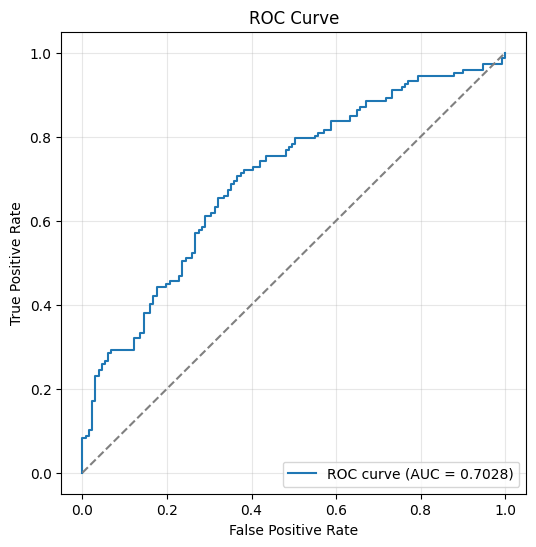

In [18]:
y_true = []
y_prob = []

for xb, yb in test_ds_prep:
    pb = best_model.predict(xb, verbose=0).reshape(-1)
    y_true.append(yb.numpy().reshape(-1))
    y_prob.append(pb)

y_true = np.concatenate(y_true).astype("int32")
y_prob = np.concatenate(y_prob)
y_pred = (y_prob >= 0.5).astype("int32")

print("Positive class for ROC/AUC:", class_names[1])
print("First 20 y_true:", y_true[:20])
print("First 20 y_prob:", np.round(y_prob[:20], 4))
print("Probability range:", float(y_prob.min()), float(y_prob.max()))
print("Probability mean/std:", float(y_prob.mean()), float(y_prob.std()))

fpr, tpr, _ = roc_curve(y_true, y_prob)
auc = roc_auc_score(y_true, y_prob)
acc = accuracy_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)

print(f"Test AUC: {auc:.4f}")
print(f"Test Accuracy: {acc:.4f}")
print("Confusion Matrix:\n", cm)
print("Classification Report:\n", classification_report(y_true, y_pred, target_names=class_names))
if auc < 0.55:
    print("AUC is below 0.55. Stop tuning ViT further and run the ResNet50 baseline with the same split.")

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()


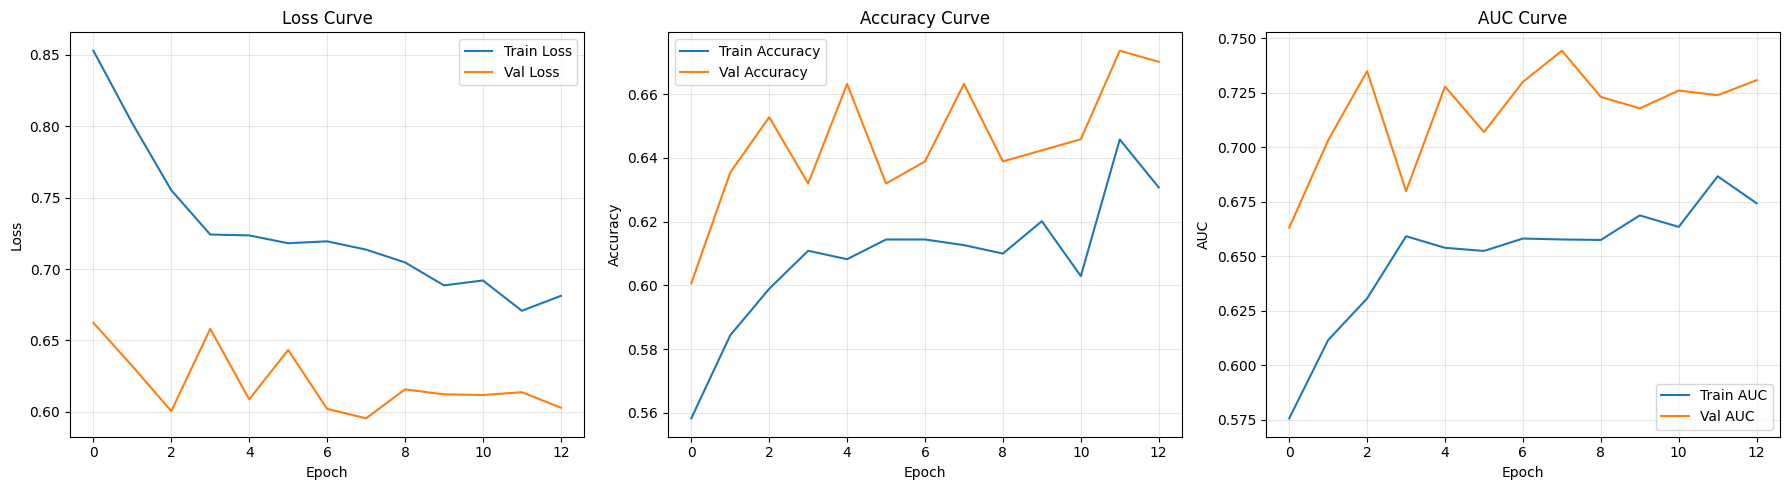

: 

In [ ]:
def merge_history(*histories):
    merged = {}
    for h in histories:
        if h is None:
            continue
        for k, v in h.history.items():
            merged.setdefault(k, []).extend(v)
    return merged

all_history = merge_history(history1, history2)

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(all_history["loss"], label="Train Loss")
plt.plot(all_history["val_loss"], label="Val Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(all_history["acc"], label="Train Accuracy")
plt.plot(all_history["val_acc"], label="Val Accuracy")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(all_history["auc"], label="Train AUC")
plt.plot(all_history["val_auc"], label="Val AUC")
plt.title("AUC Curve")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
